In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, RocCurveDisplay

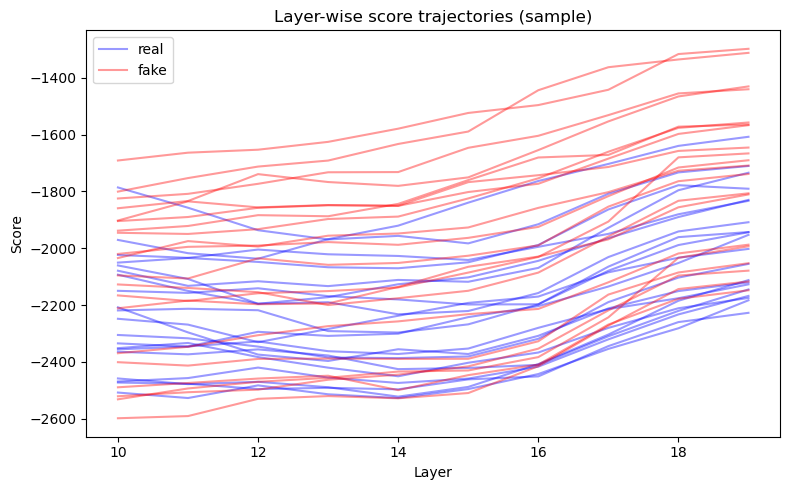

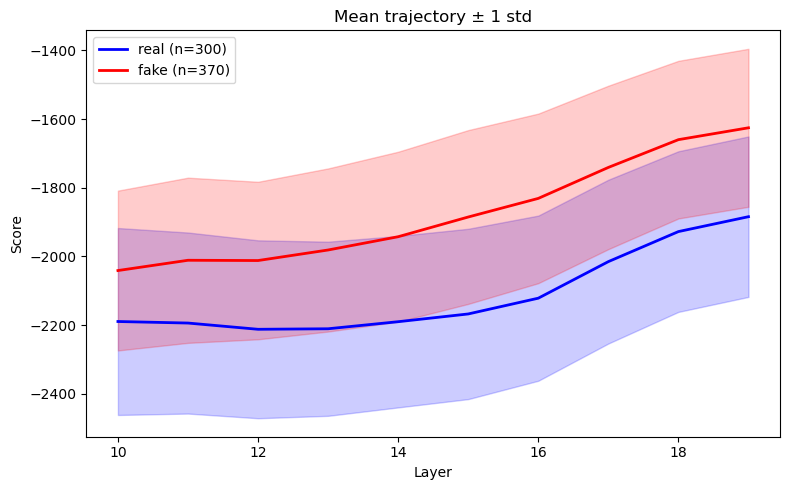

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load JSONL ────────────────────────────────────────────────────────────
def load_jsonl(path):
    meta, records = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if obj.get("_meta"):
                meta = obj
            else:
                records.append(obj)
    return meta, records

path = "/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_layerwise_ForenSynths_sample.jsonl"   # ← change this
meta, records = load_jsonl(path)

# ── 2. Detect layer columns from meta ────────────────────────────────────────
layer_ids   = meta["config"]["layers"]           # e.g. [10, 11, ..., 19]
FEATURE_COLS = [f"layer_{i}" for i in layer_ids]
layer_indices = layer_ids                         # x-axis tick values

# ── 3. Build arrays ───────────────────────────────────────────────────────────
X_test = np.array([[r[col] for col in FEATURE_COLS] for r in records])
y_test = np.array([int(r["label"]) for r in records])

# ── 4. Plot 1 – trajectory sample (first 20 real / 20 fake) ──────────────────
real_traj = X_test[y_test == 0][:20]
fake_traj = X_test[y_test == 1][:20]

plt.figure(figsize=(8, 5))
for i, s in enumerate(real_traj):
    plt.plot(layer_indices, s, color="blue", alpha=0.4,
             label="real" if i == 0 else None)
for i, s in enumerate(fake_traj):
    plt.plot(layer_indices, s, color="red", alpha=0.4,
             label="fake" if i == 0 else None)
plt.xlabel("Layer")
plt.ylabel("Score")
plt.title("Layer-wise score trajectories (sample)")
plt.legend()
plt.tight_layout()
plt.show()

# ── 5. Plot 2 – mean ± 1 std ─────────────────────────────────────────────────
real_all = X_test[y_test == 0]
fake_all = X_test[y_test == 1]

real_mean, real_std = real_all.mean(axis=0), real_all.std(axis=0)
fake_mean, fake_std = fake_all.mean(axis=0), fake_all.std(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(layer_indices, real_mean, color="blue",
         label=f"real (n={len(real_all)})", linewidth=2)
plt.fill_between(layer_indices, real_mean - real_std, real_mean + real_std,
                 color="blue", alpha=0.2)
plt.plot(layer_indices, fake_mean, color="red",
         label=f"fake (n={len(fake_all)})", linewidth=2)
plt.fill_between(layer_indices, fake_mean - fake_std, fake_mean + fake_std,
                 color="red", alpha=0.2)
plt.xlabel("Layer")
plt.ylabel("Score")
plt.title("Mean trajectory ± 1 std")
plt.legend()
plt.tight_layout()
plt.show()

AUC (layer_16 − layer_10): 0.8534


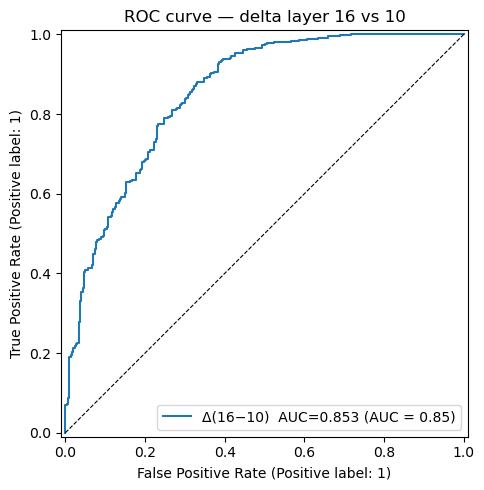

In [9]:
# ── 6. AUC on delta(layer_16 − layer_10) ─────────────────────────────────────
idx_16 = layer_ids.index(15)
idx_10 = layer_ids.index(10)

delta = X_test[:, idx_16] - X_test[:, idx_10]   # higher = more fake?

auc = roc_auc_score(y_test, delta)
# if AUC < 0.5 the delta is inverted — flip sign so curve is above diagonal
if auc < 0.5:
    delta = -delta
    auc = 1 - auc

print(f"AUC (layer_16 − layer_10): {auc:.4f}")

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, delta, name=f"Δ(16−10)  AUC={auc:.3f}", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("ROC curve — delta layer 16 vs 10")
plt.tight_layout()
plt.show()

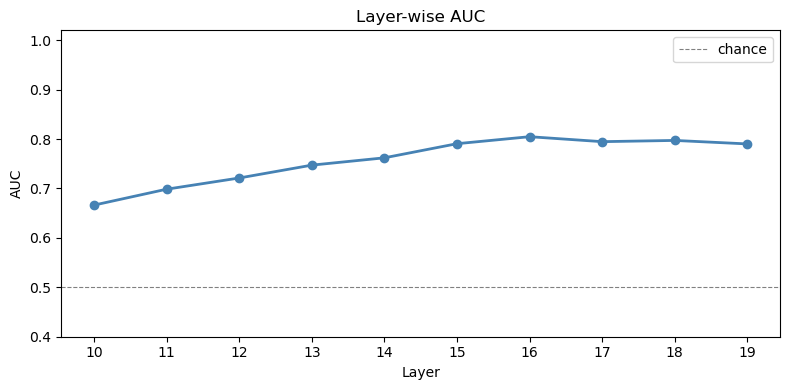

   Layer     AUC
------------------
      10  0.6664
      11  0.6985
      12  0.7212
      13  0.7472
      14  0.7620
      15  0.7906
      16  0.8048
      17  0.7947
      18  0.7972
      19  0.7902


In [10]:
# ── 7. Layer-wise AUC ─────────────────────────────────────────────────────────
aucs = []
for i, lid in enumerate(layer_ids):
    scores = X_test[:, i]
    a = roc_auc_score(y_test, scores)
    aucs.append(max(a, 1 - a))   # always report the discriminative side

plt.figure(figsize=(8, 4))
plt.plot(layer_ids, aucs, marker="o", color="steelblue", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
plt.xlabel("Layer")
plt.ylabel("AUC")
plt.title("Layer-wise AUC")
plt.ylim(0.4, 1.02)
plt.xticks(layer_ids)
plt.legend()
plt.tight_layout()
plt.show()

# print table
print(f"{'Layer':>8}  {'AUC':>6}")
print("-" * 18)
for lid, a in zip(layer_ids, aucs):
    print(f"{lid:>8}  {a:.4f}")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

REAL_COLOR = "#2196F3"
FAKE_COLOR = "#F44336"
DELTA_COLOR = "#9C27B0"


In [2]:
CSV_PATH = "/home/tischuet/zero-shot-deepfake-detection/layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_ForenSynths.csv"

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts().rename({0.0: 'real', 1.0: 'fake'})}")
print(f"\nColumn dtypes:\n{df.dtypes}")
df.head(3)


Shape: (90329, 15)

Class distribution:
label
real    45169
fake    45160
Name: count, dtype: int64

Column dtypes:
label         float64
layer_0       float64
layer_1       float64
layer_2       float64
layer_3       float64
layer_4       float64
layer_5       float64
layer_6       float64
layer_7       float64
layer_8       float64
layer_9       float64
layer_10      float64
layer_11      float64
layer_norm    float64
img_path       object
dtype: object


,label,layer_0,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,layer_9,layer_10,layer_11,layer_norm,img_path
0,1.0,-21220.625,-3265.923096,-2716.093018,-2312.273926,-1537.935791,-1056.116943,-841.910583,-664.442871,-504.726440,-533.908875,-304.572784,-284.759003,-435.317566,stylegan/car/1_fake/005459.png
1,1.0,-21220.625,-3635.416992,-2826.574951,-2336.121582,-1460.480591,-923.459595,-746.167847,-598.124329,-434.184387,-422.474792,-150.918655,-142.832458,-355.708527,stylegan/car/1_fake/005540.png
2,1.0,-21220.625,-3636.200684,-2804.950439,-2242.618652,-1325.682983,-755.283691,-596.033508,-406.345825,-177.733063,-158.556824,143.985855,173.408127,-30.214035,stylegan/car/1_fake/005620.png


In [19]:
# Identify all layer score columns (skip label, img_path, and layer_0 — constant across all samples)
layer_cols = [c for c in df.columns if c not in ("label", "img_path", "layer_0")]
n_layers   = len(layer_cols)
x_ticks    = range(n_layers)

real = df[df["label"] == 0.0]
fake = df[df["label"] == 1.0]

# Extract score matrices  (N_samples × N_layers)
real_scores = real[layer_cols].values.astype(float)
fake_scores = fake[layer_cols].values.astype(float)

print(f"Real samples : {len(real_scores)}")
print(f"Fake samples : {len(fake_scores)}")
print(f"Layers       : {layer_cols}")


Real samples : 45169
Fake samples : 45160
Layers       : ['layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10', 'layer_11', 'layer_norm']


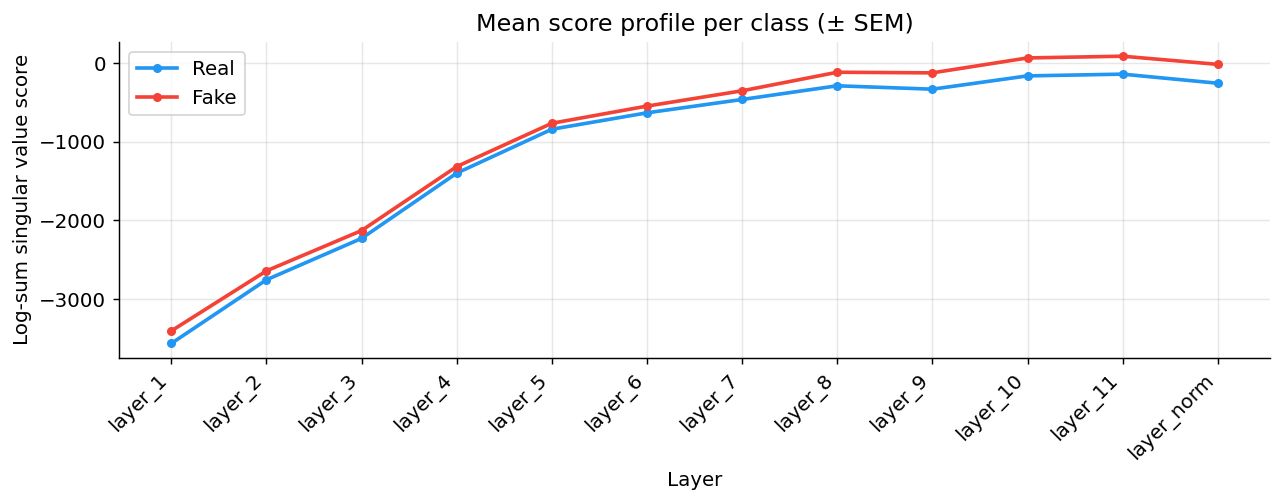

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))

for scores, color, label in [
    (real_scores, REAL_COLOR, "Real"),
    (fake_scores, FAKE_COLOR, "Fake"),
]:
    mu  = scores.mean(axis=0)
    sem = scores.std(axis=0) / np.sqrt(len(scores))
    ax.plot(x_ticks, mu, color=color, linewidth=2, label=label, marker="o", ms=4)
    ax.fill_between(x_ticks, mu - sem, mu + sem, color=color, alpha=0.15)

ax.set_xticks(x_ticks)
ax.set_xticklabels(layer_cols, rotation=45, ha="right")
ax.set_xlabel("Layer")
ax.set_ylabel("Log-sum singular value score")
ax.set_title("Mean score profile per class (± SEM)")
ax.legend()
plt.tight_layout()
plt.show()

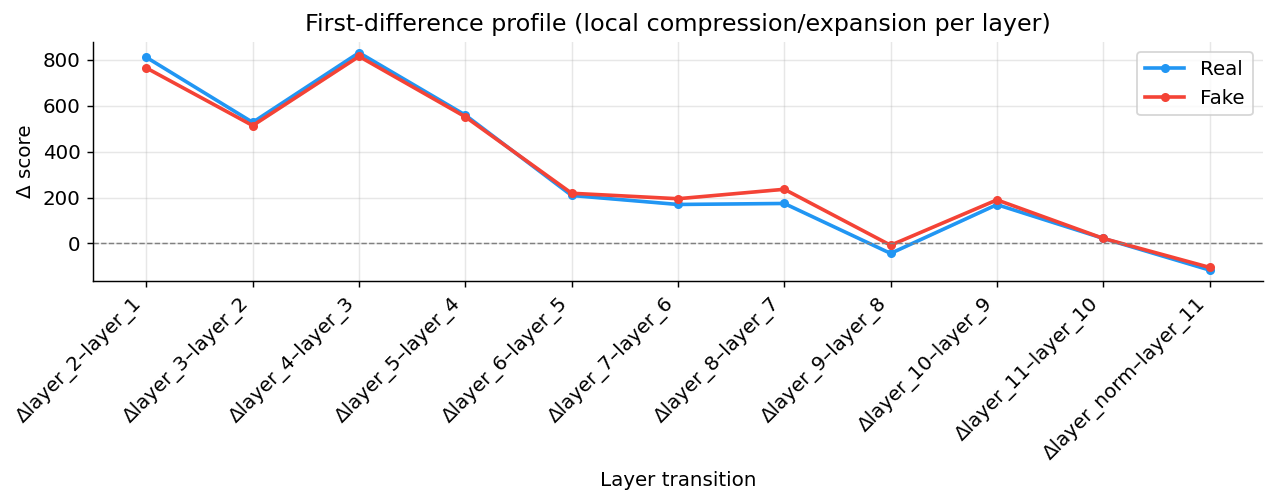

In [21]:
# First difference: Δ(l) = score(l) – score(l–1)
real_delta = np.diff(real_scores, axis=1)   # shape: (N, n_layers-1)
fake_delta = np.diff(fake_scores, axis=1)

delta_labels = [f"Δ{layer_cols[i+1]}–{layer_cols[i]}" for i in range(n_layers - 1)]
x_delta      = range(len(delta_labels))

fig, ax = plt.subplots(figsize=(10, 4))

for deltas, color, label in [
    (real_delta, REAL_COLOR, "Real"),
    (fake_delta, FAKE_COLOR, "Fake"),
]:
    mu  = deltas.mean(axis=0)
    sem = deltas.std(axis=0) / np.sqrt(len(deltas))
    ax.plot(x_delta, mu, color=color, linewidth=2, label=label, marker="o", ms=4)
    ax.fill_between(x_delta, mu - sem, mu + sem, color=color, alpha=0.15)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(x_delta)
ax.set_xticklabels(delta_labels, rotation=45, ha="right")
ax.set_xlabel("Layer transition")
ax.set_ylabel("Δ score")
ax.set_title("First-difference profile (local compression/expansion per layer)")
ax.legend()
plt.tight_layout()
plt.show()


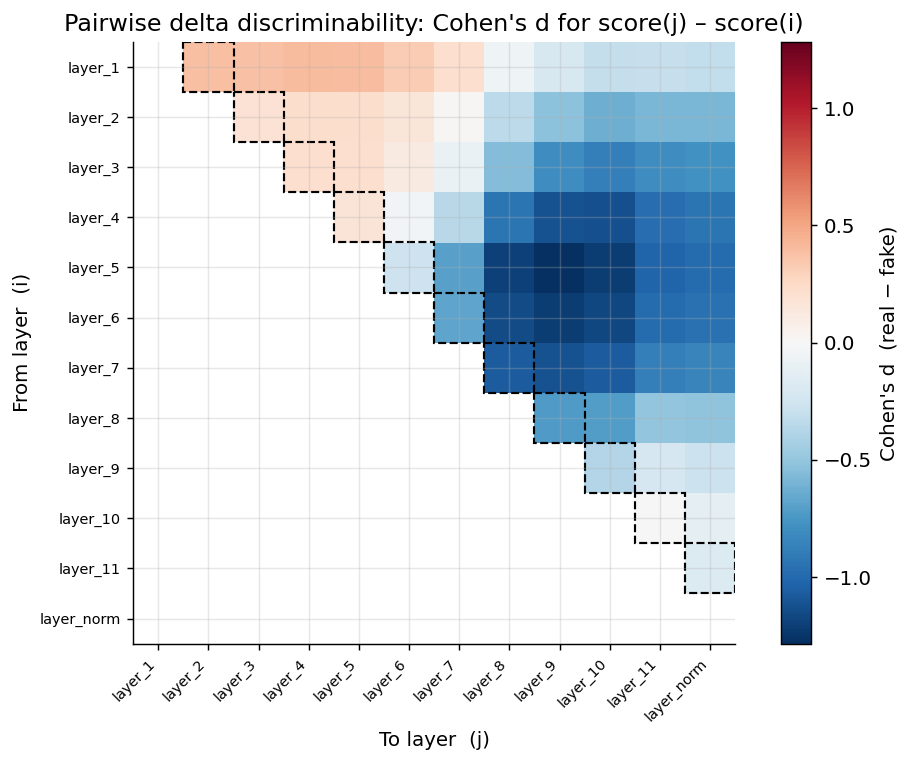

Top 5 most discriminative layer pairs:
  layer_9      – layer_5        |d| = 1.284
  layer_9      – layer_6        |d| = 1.224
  layer_10     – layer_5        |d| = 1.217
  layer_8      – layer_5        |d| = 1.196
  layer_10     – layer_6        |d| = 1.166


In [22]:
# ── Multi-scale pairwise differences ─────────────────────────────────────────
# For every pair (i, j) with j > i, compute score(j) - score(i).
# This generalises the adjacent delta to all possible layer spans.

pairs       = [(i, j) for i in range(n_layers) for j in range(i + 1, n_layers)]
pair_labels = [f"{layer_cols[j]}\u2013{layer_cols[i]}" for i, j in pairs]

real_pairs = np.stack(
    [real_scores[:, j] - real_scores[:, i] for i, j in pairs], axis=1
)   # (N_real, n_pairs)
fake_pairs = np.stack(
    [fake_scores[:, j] - fake_scores[:, i] for i, j in pairs], axis=1
)   # (N_fake, n_pairs)

# Cohen's d for every pair
d_pairs = np.array([
    cohens_d(real_pairs[:, k], fake_pairs[:, k])
    for k in range(len(pairs))
])

# Reshape into (n_layers x n_layers) matrix for heatmap
d_matrix = np.full((n_layers, n_layers), np.nan)
for k, (i, j) in enumerate(pairs):
    d_matrix[i, j] = d_pairs[k]

fig, ax = plt.subplots(figsize=(8, 6))
vmax = np.nanmax(np.abs(d_matrix))
im   = ax.imshow(d_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='upper')
plt.colorbar(im, ax=ax, label="Cohen's d  (real \u2212 fake)")
ax.set_xticks(range(n_layers))
ax.set_yticks(range(n_layers))
ax.set_xticklabels(layer_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(layer_cols, fontsize=8)
ax.set_xlabel('To layer  (j)')
ax.set_ylabel('From layer  (i)')
ax.set_title("Pairwise delta discriminability: Cohen's d for score(j) \u2013 score(i)")
# dashed outline on the super-diagonal (adjacent pairs = stride-1)
for i in range(n_layers - 1):
    ax.add_patch(plt.Rectangle((i + 0.5, i - 0.5), 1, 1,
                                fill=False, edgecolor='black', linewidth=1.2, linestyle='--'))
plt.tight_layout()
plt.show()

top5 = np.argsort(np.abs(d_pairs))[::-1][:5]
print('Top 5 most discriminative layer pairs:')
for k in top5:
    i, j = pairs[k]
    print(f'  {layer_cols[j]:12s} \u2013 {layer_cols[i]:12s}   |d| = {abs(d_pairs[k]):.3f}')


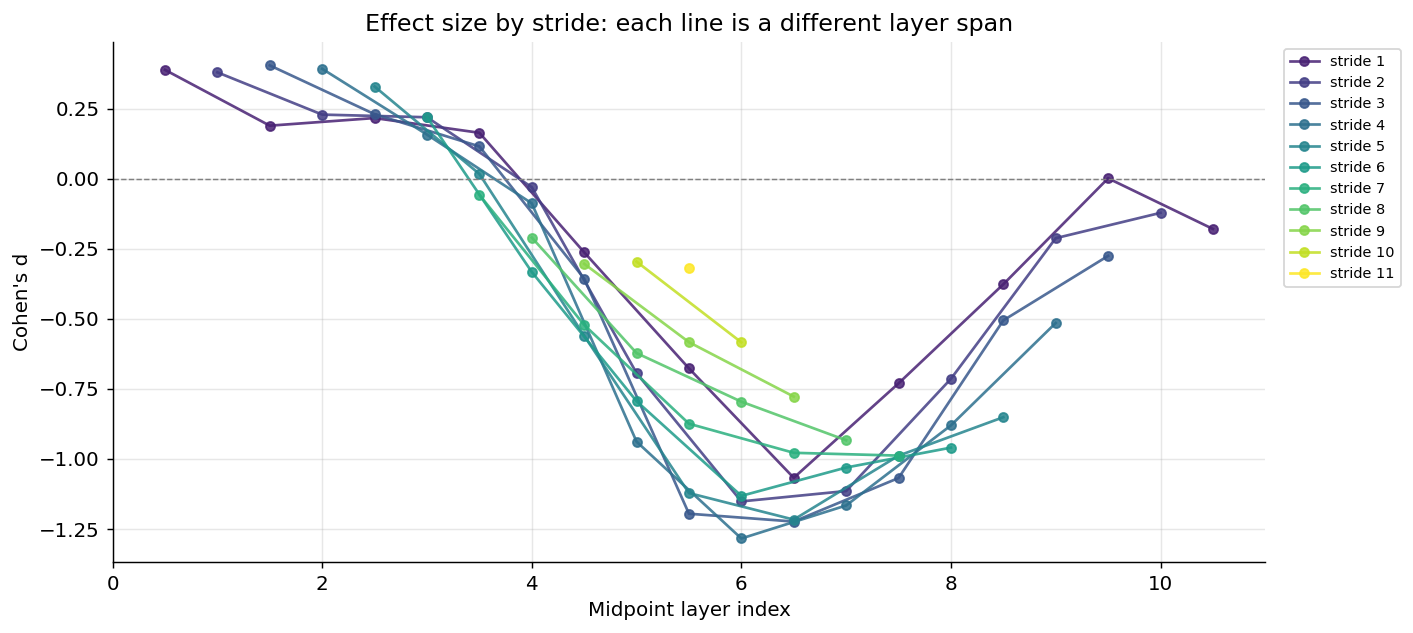

In [23]:
# ── Multi-stride mean profiles ────────────────────────────────────────────────
# Group pairs by stride and plot Cohen's d per stride.
# Stride 1 = adjacent; larger strides = coarser scale.

max_stride = n_layers - 1
fig, ax    = plt.subplots(figsize=(11, 5))
cmap       = plt.cm.viridis

for stride in range(1, max_stride + 1):
    stride_pairs = [(i, j) for i, j in pairs if j - i == stride]
    if not stride_pairs:
        continue
    idxs   = [pairs.index(p) for p in stride_pairs]
    x_pos  = [i + stride / 2 for i, j in stride_pairs]   # midpoint of the span
    d_vals = [d_pairs[k] for k in idxs]
    color  = cmap(stride / max_stride)
    ax.plot(x_pos, d_vals, marker='o', ms=5, linewidth=1.5,
            color=color, label=f'stride {stride}', alpha=0.85)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Midpoint layer index')
ax.set_ylabel("Cohen's d")
ax.set_title('Effect size by stride: each line is a different layer span')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


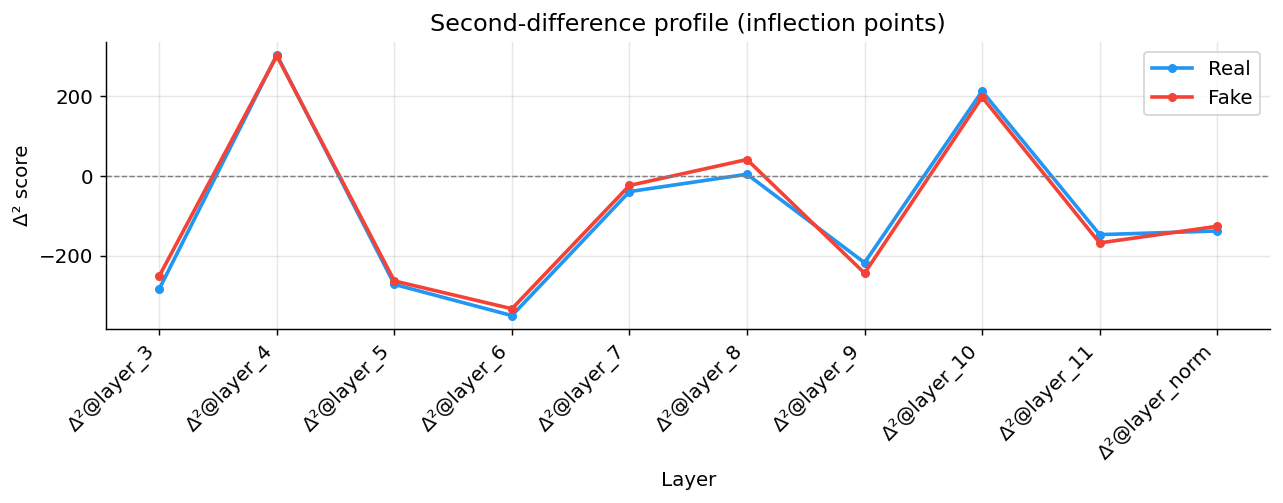

In [24]:
# Second difference: identifies inflection points (where rate of change changes most)
real_delta2 = np.diff(real_scores, n=2, axis=1)
fake_delta2 = np.diff(fake_scores, n=2, axis=1)

delta2_labels = [f"Δ²@{layer_cols[i+2]}" for i in range(n_layers - 2)]
x_delta2      = range(len(delta2_labels))

fig, ax = plt.subplots(figsize=(10, 4))

for d2, color, label in [
    (real_delta2, REAL_COLOR, "Real"),
    (fake_delta2, FAKE_COLOR, "Fake"),
]:
    mu  = d2.mean(axis=0)
    sem = d2.std(axis=0) / np.sqrt(len(d2))
    ax.plot(x_delta2, mu, color=color, linewidth=2, label=label, marker="o", ms=4)
    ax.fill_between(x_delta2, mu - sem, mu + sem, color=color, alpha=0.15)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(x_delta2)
ax.set_xticklabels(delta2_labels, rotation=45, ha="right")
ax.set_xlabel("Layer")
ax.set_ylabel("Δ² score")
ax.set_title("Second-difference profile (inflection points)")
ax.legend()
plt.tight_layout()
plt.show()


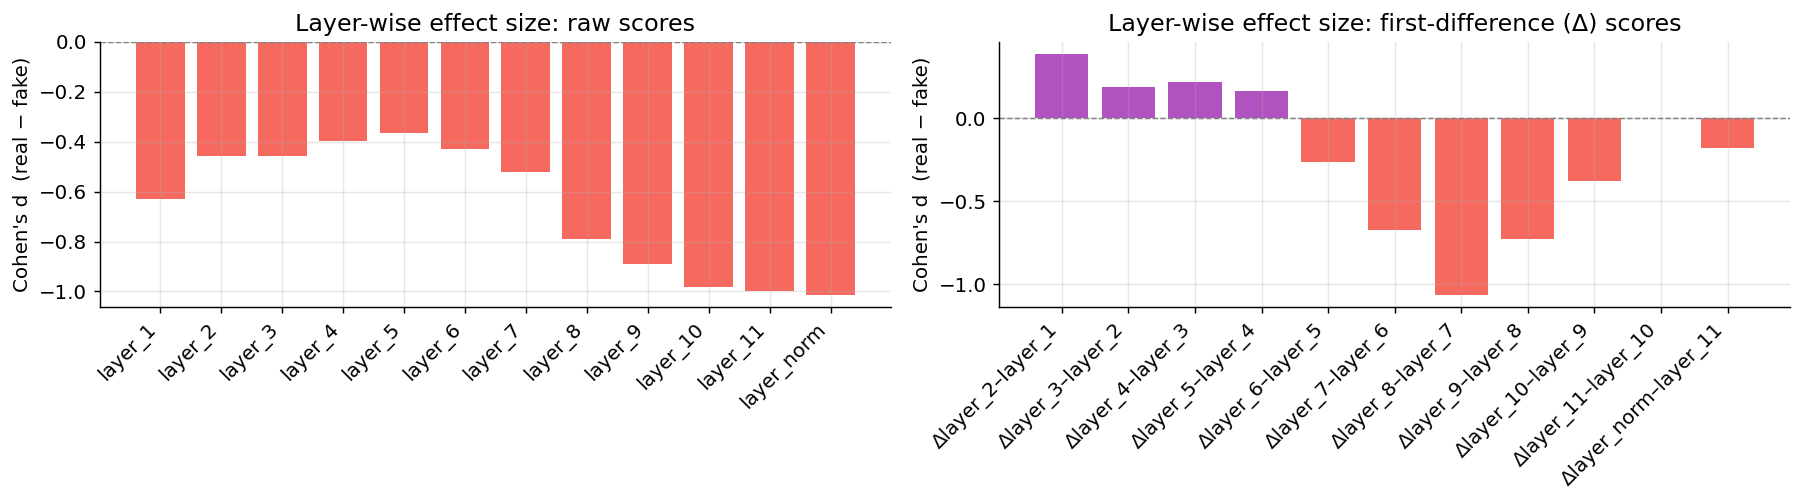


Top 3 most discriminative raw layers:
  layer_norm       |d| = 1.012
  layer_11         |d| = 0.999
  layer_10         |d| = 0.982

Top 3 most discriminative delta transitions:
  Δlayer_8–layer_7           |d| = 1.068
  Δlayer_9–layer_8           |d| = 0.731
  Δlayer_7–layer_6           |d| = 0.677


In [25]:
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / (pooled_std + 1e-12)

# Effect size at each raw layer
d_raw   = [cohens_d(real_scores[:, i], fake_scores[:, i]) for i in range(n_layers)]

# Effect size at each first-difference transition
d_delta = [cohens_d(real_delta[:, i],  fake_delta[:, i])  for i in range(len(delta_labels))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw scores
axes[0].bar(x_ticks,  d_raw,   color=[REAL_COLOR if d > 0 else FAKE_COLOR for d in d_raw],  alpha=0.8)
axes[0].set_xticks(x_ticks)
axes[0].set_xticklabels(layer_cols, rotation=45, ha="right")
axes[0].set_ylabel("Cohen's d  (real − fake)")
axes[0].set_title("Layer-wise effect size: raw scores")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")

# Delta scores
axes[1].bar(x_delta, d_delta, color=[DELTA_COLOR if d > 0 else FAKE_COLOR for d in d_delta], alpha=0.8)
axes[1].set_xticks(x_delta)
axes[1].set_xticklabels(delta_labels, rotation=45, ha="right")
axes[1].set_ylabel("Cohen's d  (real − fake)")
axes[1].set_title("Layer-wise effect size: first-difference (Δ) scores")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

print("\nTop 3 most discriminative raw layers:")
top_raw = sorted(range(n_layers), key=lambda i: abs(d_raw[i]), reverse=True)[:3]
for i in top_raw:
    print(f"  {layer_cols[i]:15s}  |d| = {abs(d_raw[i]):.3f}")

print("\nTop 3 most discriminative delta transitions:")
top_delta = sorted(range(len(d_delta)), key=lambda i: abs(d_delta[i]), reverse=True)[:3]
for i in top_delta:
    print(f"  {delta_labels[i]:25s}  |d| = {abs(d_delta[i]):.3f}")


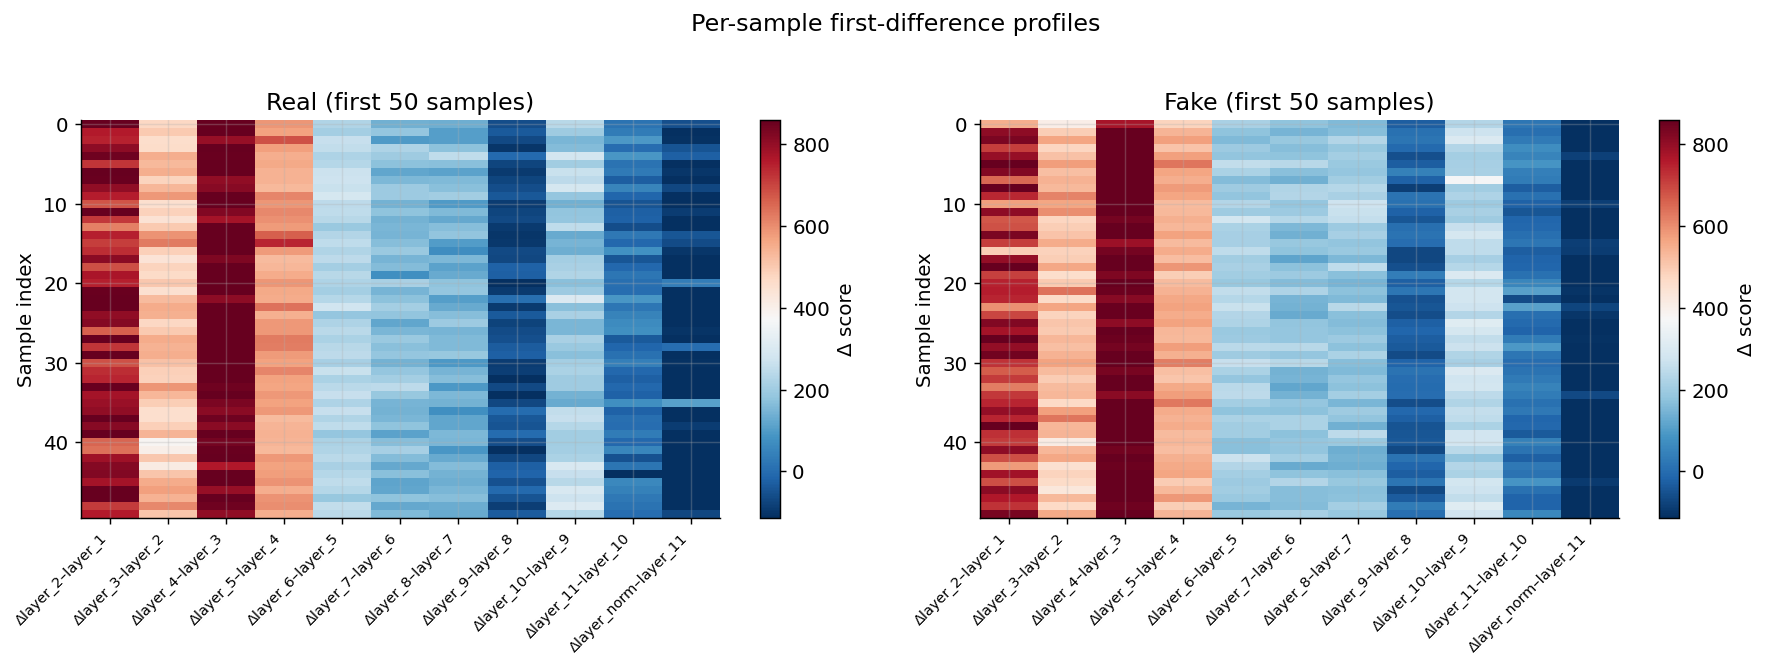

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, title in [
    (axes[0], real_delta[:50], f"Real (first {min(50, len(real_delta))} samples)"),
    (axes[1], fake_delta[:50], f"Fake (first {min(50, len(fake_delta))} samples)"),
]:
    im = ax.imshow(scores, aspect="auto", cmap="RdBu_r",
                   vmin=np.percentile(np.concatenate([real_delta, fake_delta]), 5),
                   vmax=np.percentile(np.concatenate([real_delta, fake_delta]), 95))
    ax.set_xticks(range(len(delta_labels)))
    ax.set_xticklabels(delta_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Sample index")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Δ score")

plt.suptitle("Per-sample first-difference profiles", y=1.02)
plt.tight_layout()
plt.show()


Most discriminative delta: Δlayer_8–layer_7  (|d| = 1.068)


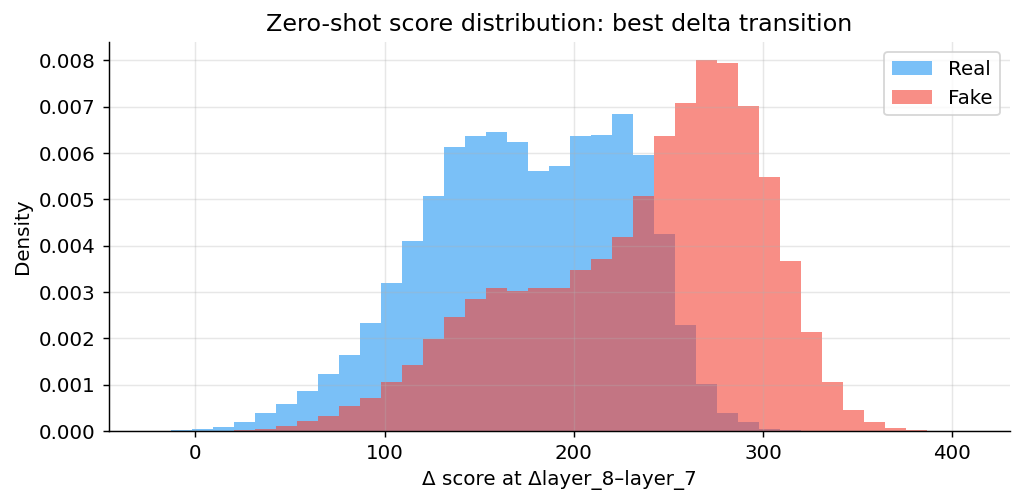


AUC (zero-shot, single delta feature): 0.7779
Note: AUC is threshold-free — no label supervision used for classification.


In [27]:
# Zero-shot classification: use the single most discriminative delta as a scalar score
best_delta_idx = int(np.argmax(np.abs(d_delta)))
print(f"Most discriminative delta: {delta_labels[best_delta_idx]}  (|d| = {abs(d_delta[best_delta_idx]):.3f})")

zs_real = real_delta[:, best_delta_idx]
zs_fake = fake_delta[:, best_delta_idx]

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(
    min(zs_real.min(), zs_fake.min()),
    max(zs_real.max(), zs_fake.max()),
    40
)
ax.hist(zs_real, bins=bins, alpha=0.6, color=REAL_COLOR, label="Real", density=True)
ax.hist(zs_fake, bins=bins, alpha=0.6, color=FAKE_COLOR, label="Fake", density=True)
ax.set_xlabel(f"Δ score at {delta_labels[best_delta_idx]}")
ax.set_ylabel("Density")
ax.set_title("Zero-shot score distribution: best delta transition")
ax.legend()
plt.tight_layout()
plt.show()

# Threshold-free AUC (no labels used for threshold)
from sklearn.metrics import roc_auc_score
y_true   = np.array([0] * len(zs_real) + [1] * len(zs_fake))
y_scores = np.concatenate([zs_real, zs_fake])
auc = roc_auc_score(y_true, y_scores)
print(f"\nAUC (zero-shot, single delta feature): {auc:.4f}")
print("Note: AUC is threshold-free — no label supervision used for classification.")


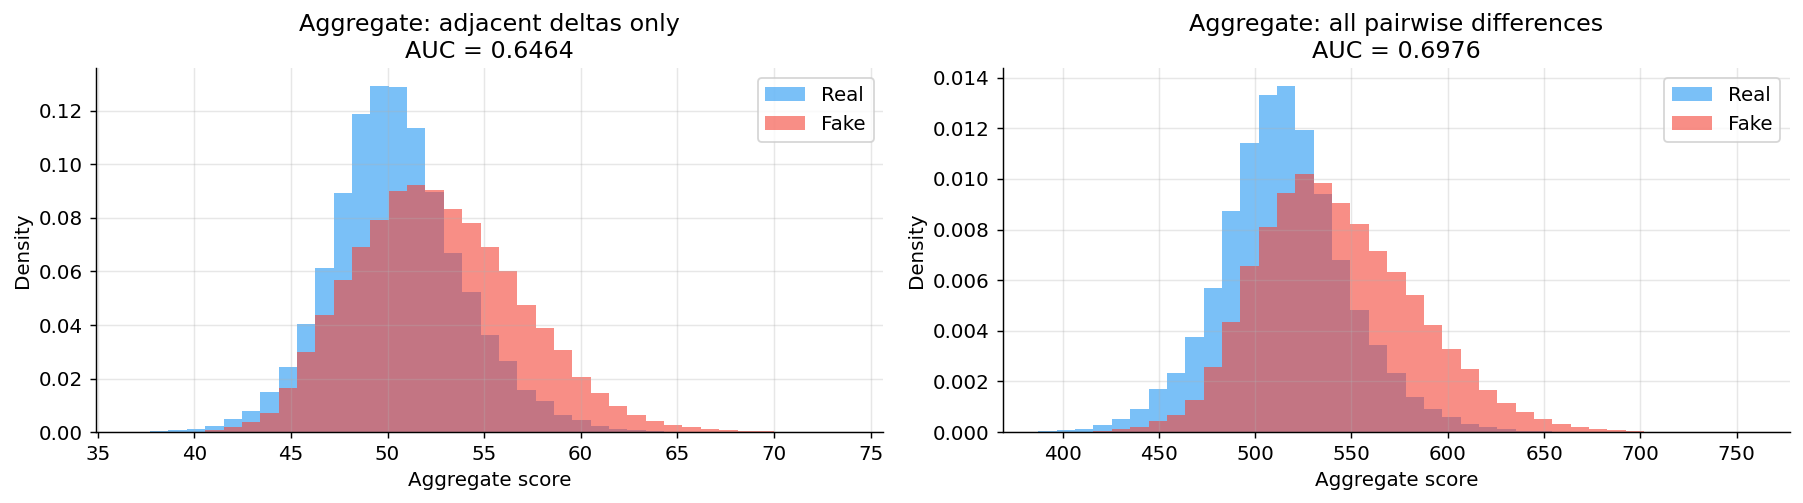

In [28]:
# Aggregate: normalize each delta channel by its std across ALL samples (unsupervised),
# then sum.  No class labels used — only the marginal distribution of each channel.
# Two variants: (a) adjacent deltas only, (b) all pairwise differences.

# (a) Adjacent deltas
all_delta   = np.concatenate([real_delta, fake_delta], axis=0)
channel_std = all_delta.std(axis=0) + 1e-12
real_agg_adj = (real_delta / channel_std).sum(axis=1)
fake_agg_adj = (fake_delta / channel_std).sum(axis=1)

# (b) All pairwise differences
all_pairs    = np.concatenate([real_pairs, fake_pairs], axis=0)
pairs_std    = all_pairs.std(axis=0) + 1e-12
real_agg_all = (real_pairs / pairs_std).sum(axis=1)
fake_agg_all = (fake_pairs / pairs_std).sum(axis=1)

from sklearn.metrics import roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, r, f, title in [
    (axes[0], real_agg_adj, fake_agg_adj, 'Aggregate: adjacent deltas only'),
    (axes[1], real_agg_all, fake_agg_all, 'Aggregate: all pairwise differences'),
]:
    lo = min(r.min(), f.min())
    hi = max(r.max(), f.max())
    bins = np.linspace(lo, hi, 40)
    ax.hist(r, bins=bins, alpha=0.6, color=REAL_COLOR, label='Real', density=True)
    ax.hist(f, bins=bins, alpha=0.6, color=FAKE_COLOR, label='Fake', density=True)
    y_true = np.array([0] * len(r) + [1] * len(f))
    auc    = roc_auc_score(y_true, np.concatenate([r, f]))
    ax.set_title(f'{title}\nAUC = {auc:.4f}')
    ax.set_xlabel('Aggregate score')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()


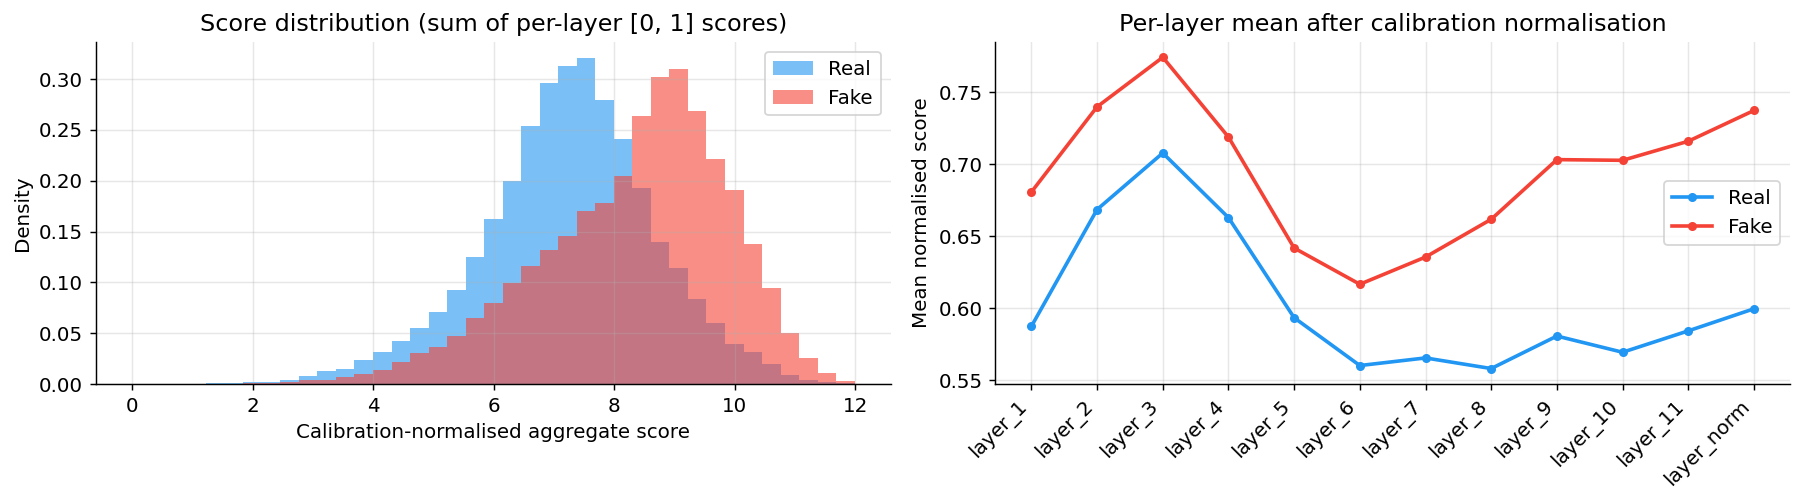

AUC (calibration-normalised aggregate): 0.7108

Calibration stats (first 3 layers):
  layer_1       min=-4571.65  max=-2860.14
  layer_2       min=-3817.43  max=-2230.38
  layer_3       min=-3276.41  max=-1800.18


In [29]:
# ── Calibration-normalised aggregate score ───────────────────────────────────
# Each layer score is scaled to [0, 1] using min/max from a calibration set,
# then summed across layers.  Labels in the calibration set are NOT used —
# only the marginal score distribution per layer.

CALIB_PATH = "/home/tischuet/zero-shot-deepfake-detection/layers_vit_base_patch16_clip_quickgelu_224_metaclip_400m_Imagenet.csv"

calib_df     = pd.read_csv(CALIB_PATH)
calib_scores = calib_df[layer_cols].values.astype(float)   # (N_calib, n_layers)

# Min / max per layer from calibration data only
calib_min   = calib_scores.min(axis=0)   # (n_layers,)
calib_max   = calib_scores.max(axis=0)   # (n_layers,)
calib_range = calib_max - calib_min

# Guard against constant layers (range == 0)
calib_range = np.where(calib_range == 0, 1.0, calib_range)

def minmax_normalise(scores):
    """Apply calibration min/max to any score matrix (N x n_layers)."""
    normed = (scores - calib_min) / calib_range
    return np.clip(normed, 0, 1)   # values outside calib range clamp to [0, 1]

real_normed = minmax_normalise(real_scores)   # (N_real, n_layers)
fake_normed = minmax_normalise(fake_scores)   # (N_fake, n_layers)

# Aggregate: sum normalised scores across all layers
real_calib_agg = real_normed.sum(axis=1)   # (N_real,)
fake_calib_agg = fake_normed.sum(axis=1)   # (N_fake,)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
lo   = min(real_calib_agg.min(), fake_calib_agg.min())
hi   = max(real_calib_agg.max(), fake_calib_agg.max())
bins = np.linspace(lo, hi, 40)
axes[0].hist(real_calib_agg, bins=bins, alpha=0.6, color=REAL_COLOR, label='Real', density=True)
axes[0].hist(fake_calib_agg, bins=bins, alpha=0.6, color=FAKE_COLOR, label='Fake', density=True)
axes[0].set_xlabel('Calibration-normalised aggregate score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score distribution (sum of per-layer [0, 1] scores)')
axes[0].legend()

# Per-layer mean normalised score — shows which layers contribute most after normalisation
axes[1].plot(range(n_layers), real_normed.mean(axis=0),
             color=REAL_COLOR, marker='o', ms=4, linewidth=2, label='Real')
axes[1].plot(range(n_layers), fake_normed.mean(axis=0),
             color=FAKE_COLOR, marker='o', ms=4, linewidth=2, label='Fake')
axes[1].set_xticks(range(n_layers))
axes[1].set_xticklabels(layer_cols, rotation=45, ha='right')
axes[1].set_ylabel('Mean normalised score')
axes[1].set_title('Per-layer mean after calibration normalisation')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── AUC ──────────────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
y_true = np.array([0] * len(real_calib_agg) + [1] * len(fake_calib_agg))
auc    = roc_auc_score(y_true, np.concatenate([real_calib_agg, fake_calib_agg]))
print(f'AUC (calibration-normalised aggregate): {auc:.4f}')
print(f'\nCalibration stats (first 3 layers):')
for i in range(min(3, n_layers)):
    print(f'  {layer_cols[i]:12s}  min={calib_min[i]:.2f}  max={calib_max[i]:.2f}')
